# GCSE and A-level Value Added in Mathematics — a Bayesian model

We want to understand how much of a school's value-added effect at KS4 (GCSE) carries through to KS5 (A-level), starting with Mathematics before generalising to other subjects.

Both value-added measures published by the DfE are noisy point estimates — each comes with a 95% confidence interval that varies school to school (smaller cohorts give wider intervals). Regressing one point estimate on the other and ignoring that noise would understate the true uncertainty in the relationship and can bias the estimated slope towards zero (attenuation bias). Instead we build a Bayesian **errors-in-variables (measurement-error) regression**: each school's *true* GCSE and A-level maths value-added are latent quantities, and the published confidence intervals define the observation noise around them.

We follow the standard Bayesian workflow: prior predictive check -> fit -> diagnostics -> posterior predictive check -> interpret.

In [1]:
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm

%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.3.1


## Data

`data/maths-value-add-errors.csv` has one row per school (`URN`) with:
- the A-level Maths value-added score and its 95% confidence interval, and
- the GCSE Maths Progress 8 measure (`P8MEAMAT`) and its 95% confidence interval.

We convert each interval to an implied standard error, assuming a 95% normal confidence interval: `se = (upper - lower) / (2 * 1.96)`. We keep only schools where both the GCSE and A-level measures are present — schools with just one (e.g. no sixth form, or no GCSE cohort recorded) are out of scope for this relationship.

In [2]:
raw = pd.read_csv("data/maths-value-add-errors.csv")

df = (
    raw.rename(
        columns={
            "A-level Maths VA": "alevel_va",
            "A-level Maths VA lower": "alevel_lower",
            "A-level Maths VA upper": "alevel_upper",
            "P8MEAMAT": "gcse_va",
            "P8MEAMAT lower": "gcse_lower",
            "P8MEAMAT upper": "gcse_upper",
        }
    )
    .dropna(subset=["alevel_va", "gcse_va"])
    .reset_index(drop=True)
)

Z_95 = 1.96
df["alevel_se"] = (df["alevel_upper"] - df["alevel_lower"]) / (2 * Z_95)
df["gcse_se"] = (df["gcse_upper"] - df["gcse_lower"]) / (2 * Z_95)

print(f"{len(df)} schools with both GCSE and A-level maths value-added")
df[["alevel_va", "alevel_se", "gcse_va", "gcse_se"]].describe()

1622 schools with both GCSE and A-level maths value-added


,alevel_va,alevel_se,gcse_va,gcse_se
count,1622.000000,1622.000000,1622.000000,1622.000000
mean,-0.093397,0.263356,0.140136,0.111871
std,0.498176,0.101383,0.469802,0.022130
min,-2.170000,0.071429,-2.290000,0.071429
25%,-0.390000,0.183673,-0.150000,0.096939
50%,-0.050000,0.250000,0.130000,0.107143
75%,0.240000,0.329082,0.420000,0.119898
max,1.730000,0.502551,2.490000,0.369898


## Exploratory look

A scatter of the two point estimates, with error bars showing each school's known uncertainty, before any model is fit.

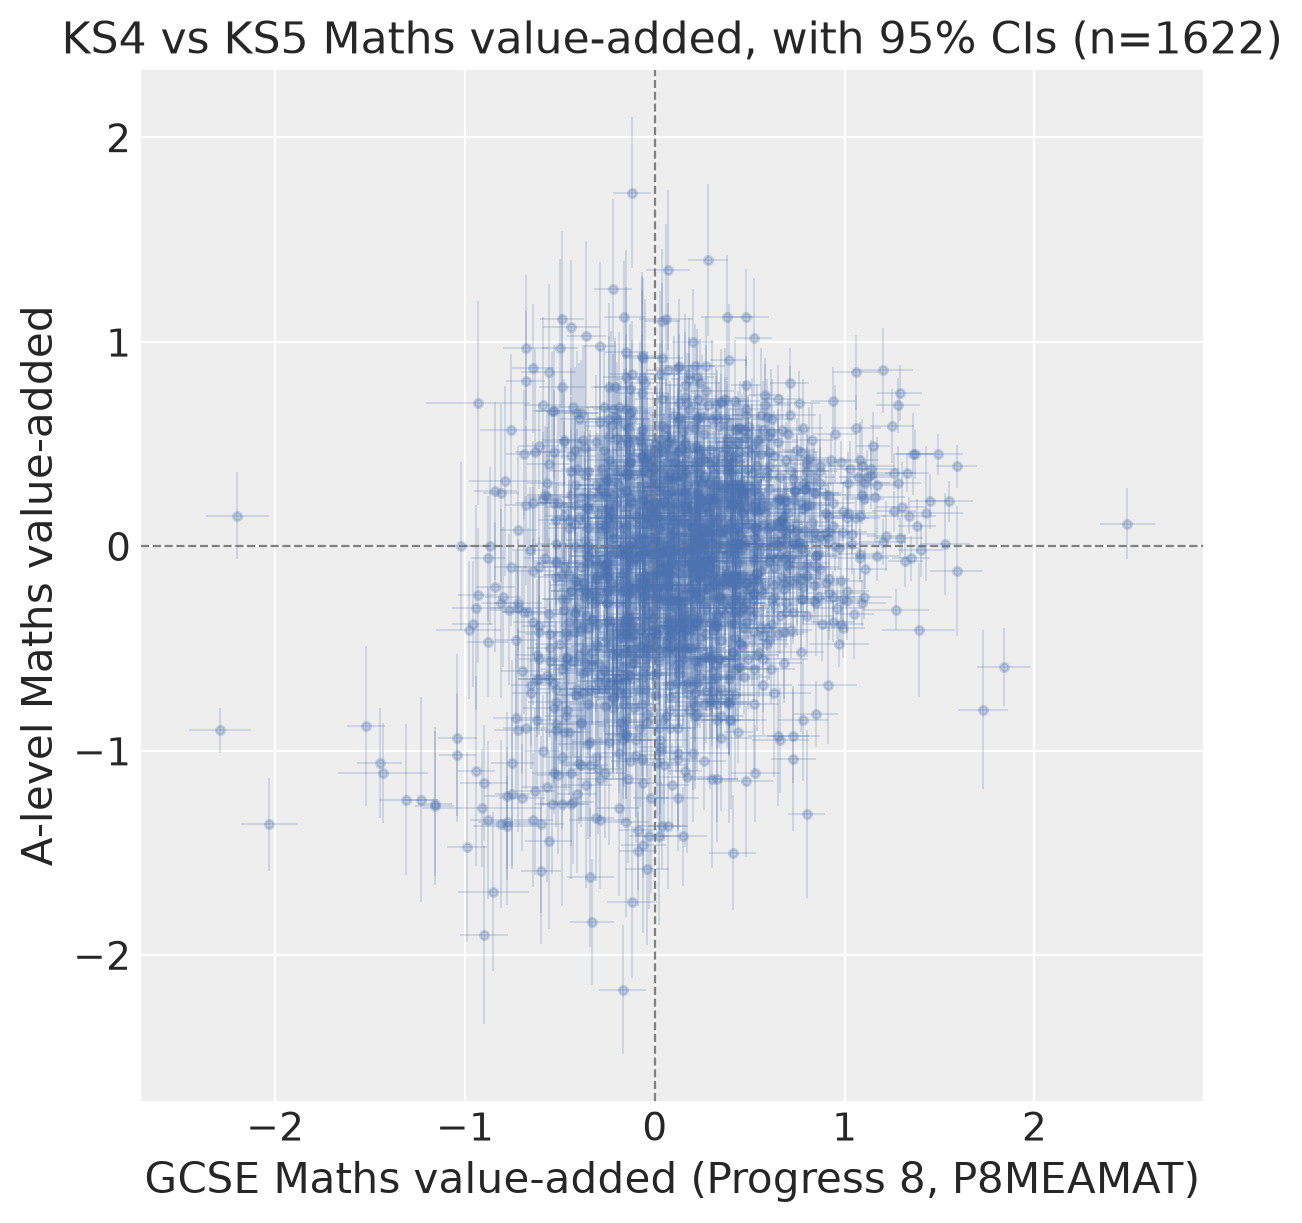

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    df["gcse_va"], df["alevel_va"],
    xerr=df["gcse_se"], yerr=df["alevel_se"],
    fmt="o", color="#4C72B0", ecolor="#4C72B0",
    alpha=0.25, markersize=3, elinewidth=0.6,
)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("GCSE Maths value-added (Progress 8, P8MEAMAT)")
ax.set_ylabel("A-level Maths value-added")
ax.set_title(f"KS4 vs KS5 Maths value-added, with 95% CIs (n={len(df)})")
plt.show()

## Model: Bayesian errors-in-variables regression

For each school $i$ we don't observe the *true* value-added $x_i$ (GCSE) and $y_i$ (A-level) directly — we observe noisy estimates $x_i^{obs}, y_i^{obs}$ with known standard errors $\sigma^x_i, \sigma^y_i$ derived from the published confidence intervals.

$$
\begin{aligned}
x_i &\sim \text{Normal}(\mu_x, \tau_x) \\
x_i^{obs} &\sim \text{Normal}(x_i, \sigma^x_i) \\[4pt]
y_i &= \alpha + \beta x_i + \epsilon_i, \quad \epsilon_i \sim \text{Normal}(0, \tau_y) \\
y_i^{obs} &\sim \text{Normal}(y_i, \sigma^y_i)
\end{aligned}
$$

$\beta$ is the quantity we care about: how much of a school's *true* GCSE maths value-added carries over to *true* A-level maths value-added, correcting for the fact both are noisy estimates rather than the truth. $x_i$ and $y_i$ are modelled with a non-centered parameterisation ($x_i = \mu_x + \tau_x \cdot z_i$) for better sampling geometry.

In [4]:
gcse_obs = df["gcse_va"].to_numpy()
gcse_se = df["gcse_se"].to_numpy()
alevel_obs = df["alevel_va"].to_numpy()
alevel_se = df["alevel_se"].to_numpy()
n_schools = len(df)

with pm.Model() as eiv_model:
    # true (latent) GCSE value-added per school, non-centered
    mu_x = pm.Normal("mu_x", mu=0, sigma=1)
    tau_x = pm.HalfNormal("tau_x", sigma=1)
    x_raw = pm.Normal("x_raw", mu=0, sigma=1, shape=n_schools)
    x_true = pm.Deterministic("x_true", mu_x + tau_x * x_raw)

    # structural regression: true A-level VA as a function of true GCSE VA
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    tau_y = pm.HalfNormal("tau_y", sigma=1)
    y_raw = pm.Normal("y_raw", mu=0, sigma=1, shape=n_schools)
    y_true = pm.Deterministic("y_true", alpha + beta * x_true + tau_y * y_raw)

    # measurement model: observed VA scores are noisy versions of the truth,
    # with per-school noise fixed to the published confidence interval
    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=alevel_se, observed=alevel_obs)

### Prior predictive check

Before fitting, simulate observed data from the priors alone. Value-added scores are typically in roughly [-2, 2], so this checks the priors aren't putting most of their mass somewhere implausible.

Sampling: [alevel_obs, alpha, beta, gcse_obs, mu_x, tau_x, tau_y, x_raw, y_raw]


/tmp/ipykernel_32814/4193119287.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


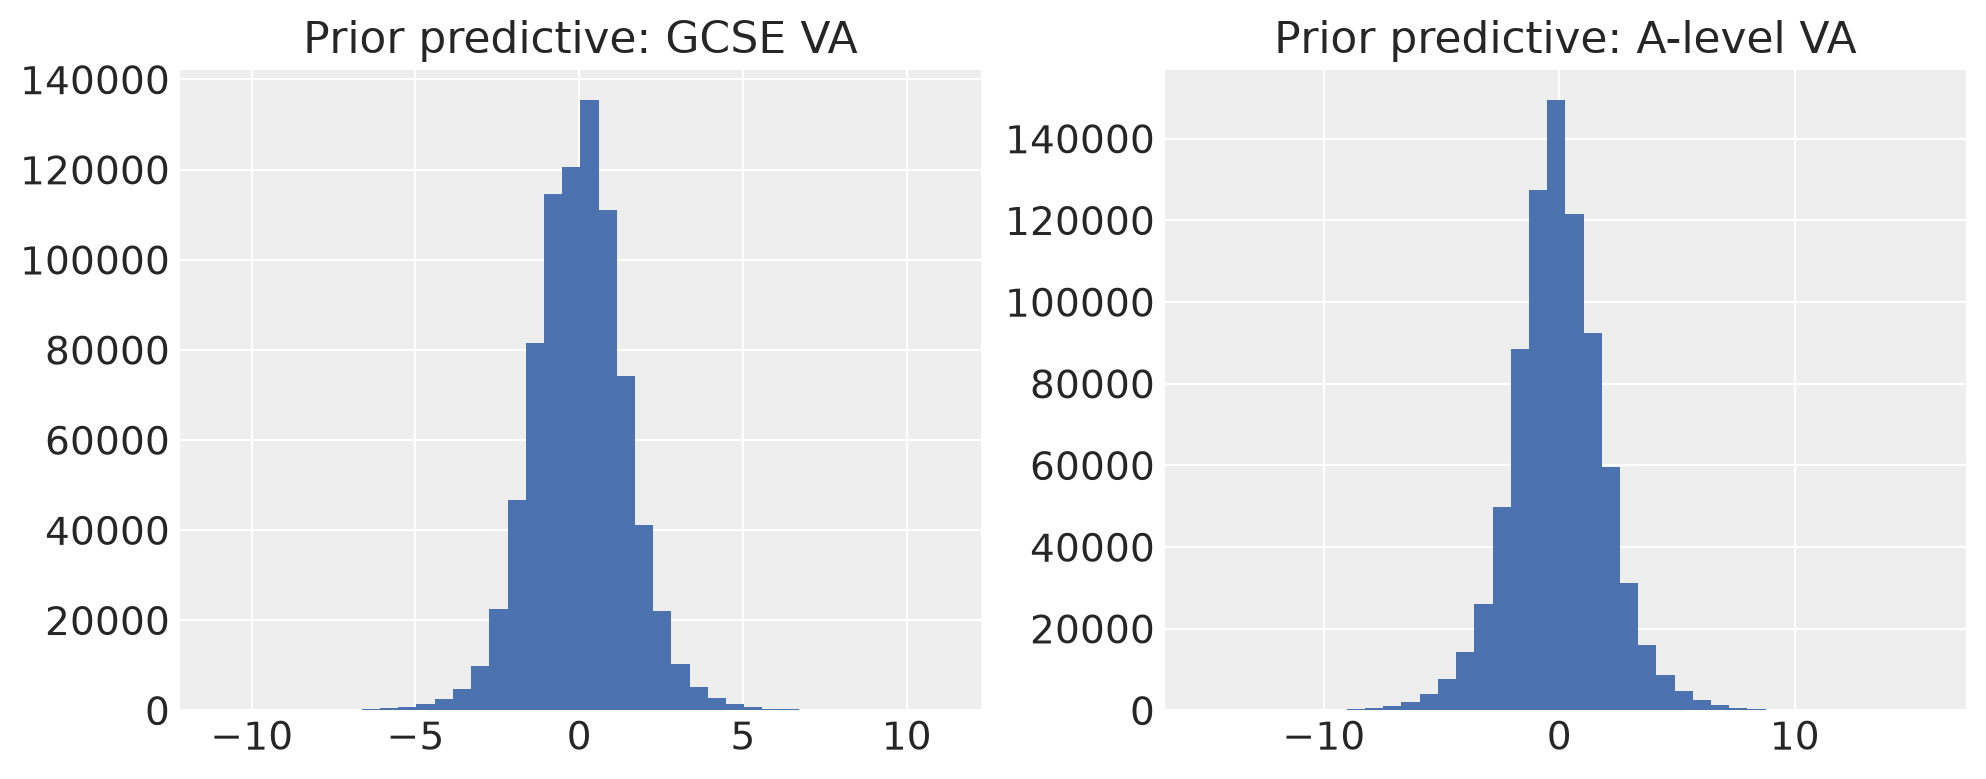

In [5]:
with eiv_model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(prior.prior_predictive["gcse_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[0].set_title("Prior predictive: GCSE VA")
axes[1].hist(prior.prior_predictive["alevel_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[1].set_title("Prior predictive: A-level VA")
plt.tight_layout()
plt.show()

### Fit

Sample the posterior with NUTS. `target_accept=0.99` and extra tuning steps are used because the latent per-school `x_true`/`y_true` parameters create a mild funnel geometry with the population-level `tau_x`/`tau_y`.

In [6]:
with eiv_model:
    idata = pm.sample(
        draws=1000, tune=2000, chains=4, target_accept=0.99,
        random_seed=RANDOM_SEED,
    )
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED)

idata.update(ppc)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, tau_y, y_raw]


Output()

Sampling: [alevel_obs, gcse_obs]


Output()

### Diagnostics

Check divergences, $\hat{R}$ and effective sample size for the population-level parameters before trusting the posterior.

In [7]:
n_divergent = int(idata.sample_stats["diverging"].sum())
print(f"Divergences: {n_divergent}")

az.summary(idata, var_names=["mu_x", "tau_x", "alpha", "beta", "tau_y"], round_to=3)

Divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_x,0.139,0.011,0.121,0.156,156.604,296.789,1.014,0.001,0.0
tau_x,0.452,0.008,0.439,0.465,326.316,754.127,1.007,0.000,0.0
alpha,-0.125,0.012,-0.145,-0.106,1038.921,1335.857,1.002,0.000,0.0
beta,0.282,0.025,0.242,0.324,522.915,925.906,1.011,0.001,0.0
tau_y,0.357,0.010,0.342,0.374,1149.707,1730.208,1.002,0.000,0.0


/tmp/ipykernel_32814/1585683059.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


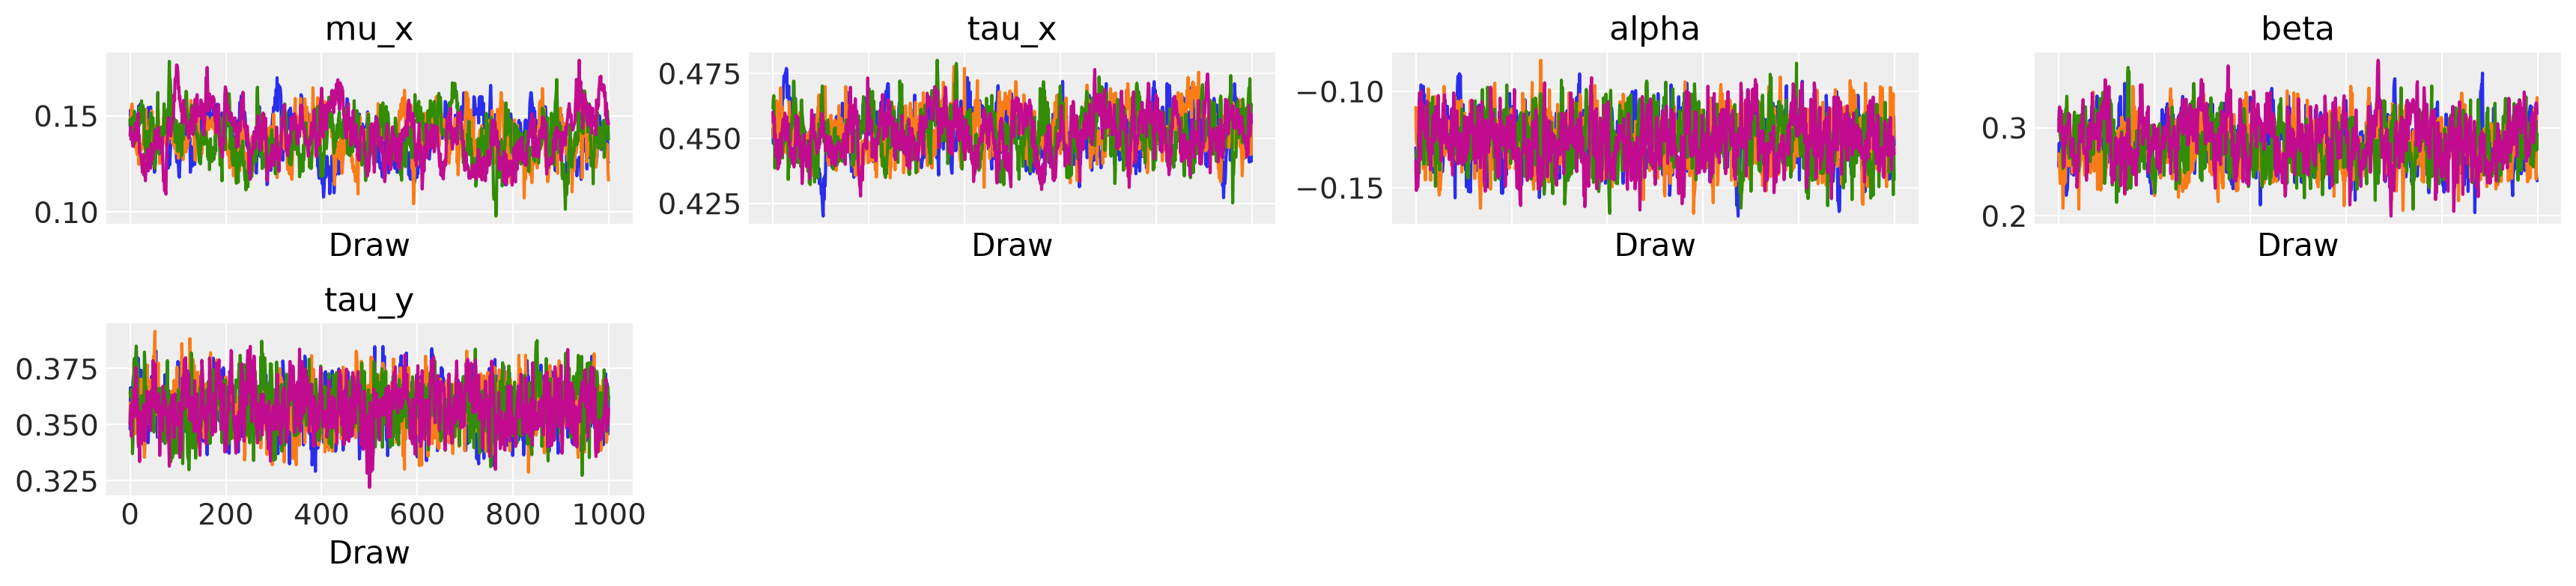

In [8]:
az.plot_trace(idata, var_names=["mu_x", "tau_x", "alpha", "beta", "tau_y"])
plt.tight_layout()

### Posterior of $\beta$

The slope relating true GCSE maths value-added to true A-level maths value-added.

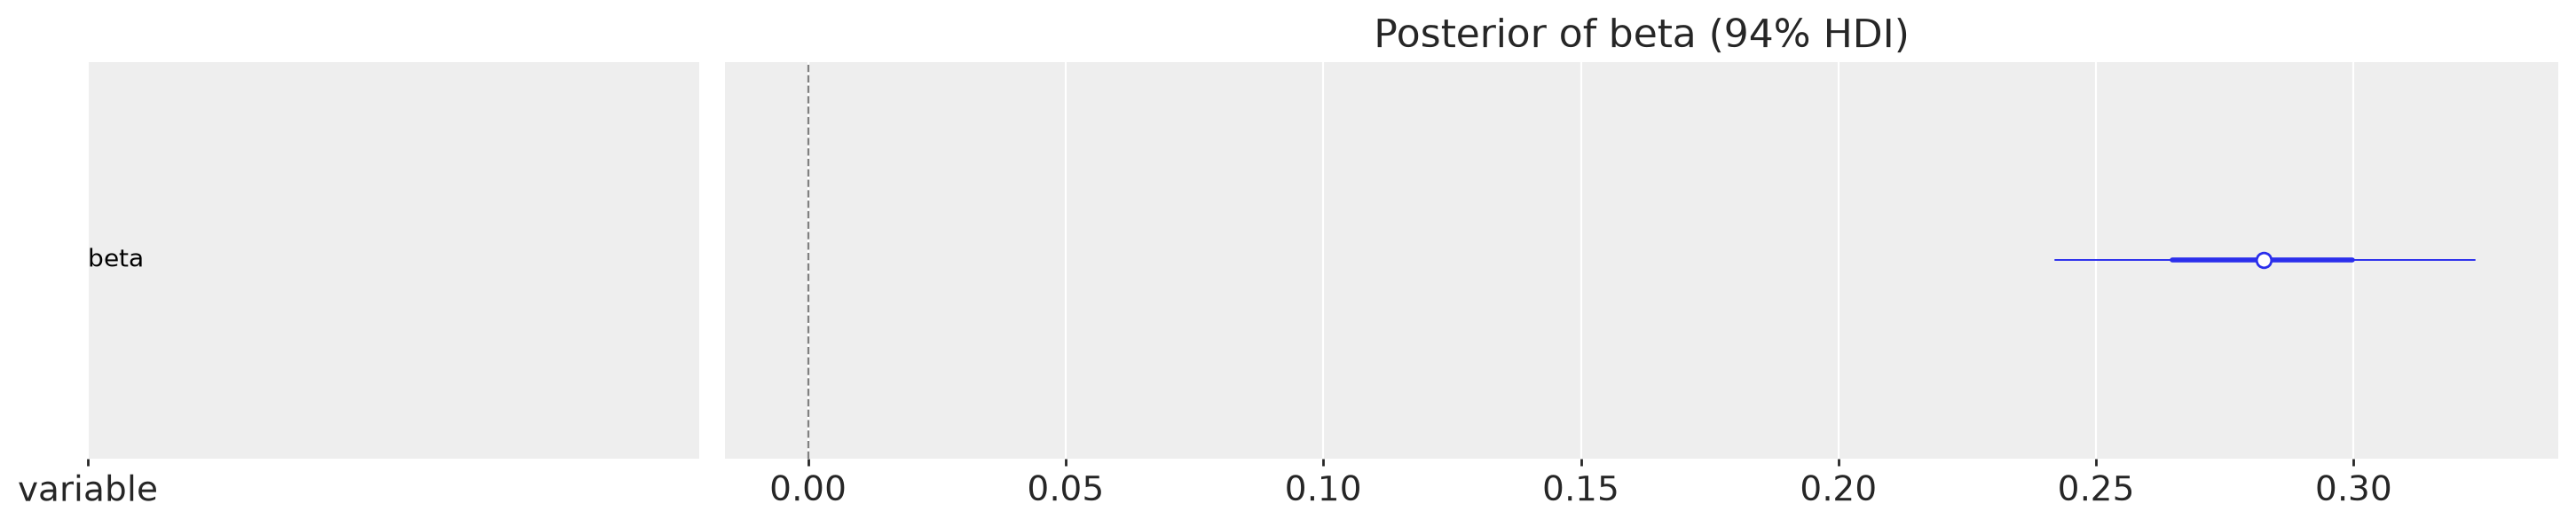

In [9]:
az.plot_forest(idata, var_names=["beta"], combined=True)
plt.axvline(0, color="grey", linewidth=0.8, linestyle="--")
plt.title("Posterior of beta (94% HDI)")
plt.show()

### Posterior predictive check

Compare the observed distribution of each measure to the model's posterior predictive draws — if the model is a reasonable fit, the observed curve should sit inside the spread of predictive draws.

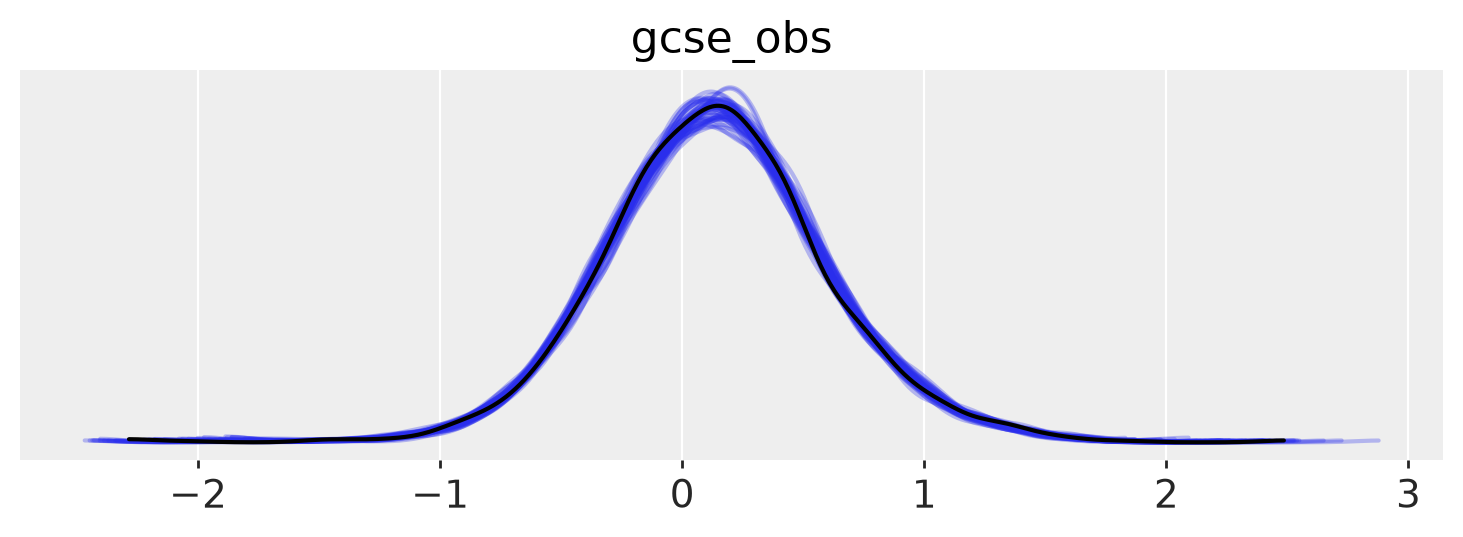

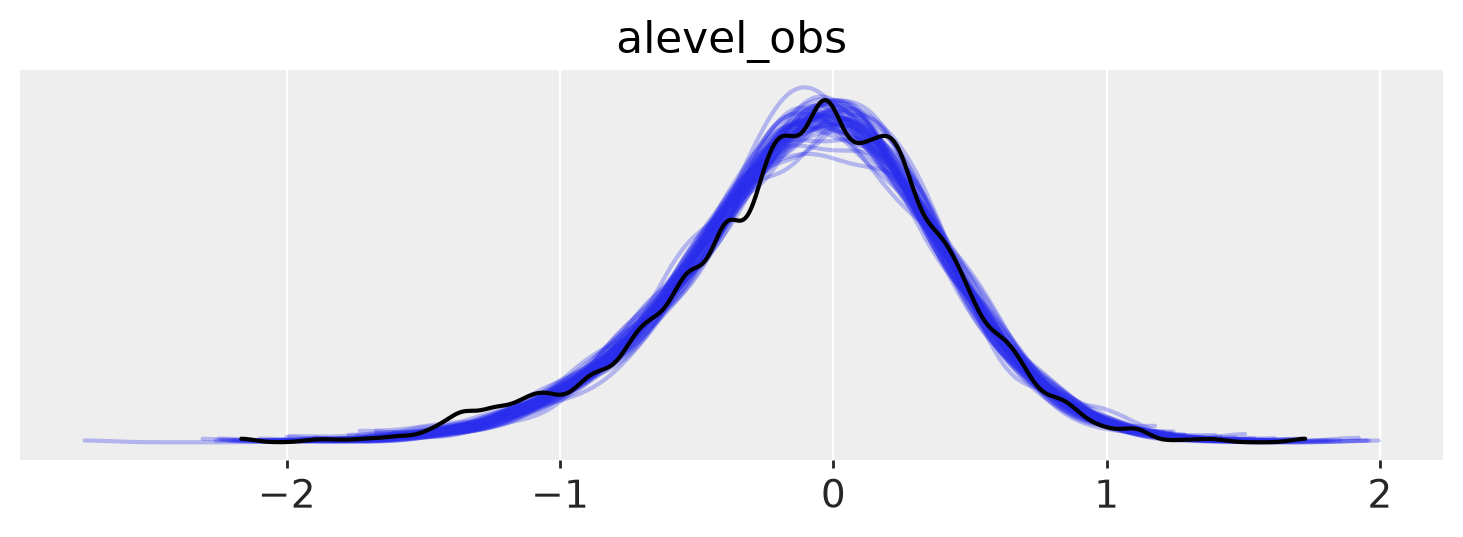

In [10]:
az.plot_ppc_dist(idata, var_names=["gcse_obs"])
plt.show()

az.plot_ppc_dist(idata, var_names=["alevel_obs"])
plt.show()

## Interpretation

`beta` is the estimated slope relating true GCSE maths value-added to true A-level maths value-added, after accounting for measurement error in both. Its posterior tells us whether — and how strongly — the two are related, without the noise in each measure attenuating the estimate the way a naive regression on the raw point estimates would.

## Next steps

- **Generalise across subjects**: reshape the wide A-level VA columns in `a-level-gcse-value-add.csv` to long format (school × subject), and extend this model to a hierarchical structure where `alpha`/`beta` are drawn per-subject from shared population distributions with partial pooling. That tells us whether GCSE-to-A-level carryover is a general phenomenon or specific to maths — subjects with few schools/small cohorts borrow strength from the population estimate rather than being fit in isolation.
- **Compare to a naive regression** on the point estimates only (no measurement-error model), to quantify how much attenuation the naive approach would have introduced.
- Only 1,622 of the 2,577 schools in `maths-value-add-errors.csv` have both a GCSE and A-level maths VA score recorded; worth checking whether that subset is representative (e.g. by school type or size) before over-generalising the conclusion.

## Accounting for selection into A-level Maths

GCSE Maths is compulsory — essentially every pupil in a school's Progress 8 cohort sits it. A-level Maths is not: schools typically require a grade 7 (or higher) at GCSE, so the A-level Maths VA score is measured on a self-selected, higher-attaining subset, and *how selective* a school chooses to be is a school-level policy, not a constant.

The good news is that DfE's A-level VA methodology already benchmarks each pupil against the national average grade for pupils with the *same* prior attainment doing that subject, so selection on prior attainment (the grade-7 rule itself) is largely already priced into the outcome. What it can't correct for is a school-specific confound: if stricter/looser selection policies correlate with things that independently drive strong A-level results (a small elite class vs. a broad one, for instance), `beta` from the first model could be picking up some of that selection effect rather than pure GCSE-to-A-level carryover.

The updated data now includes `A-level Maths entries` (number of pupils sitting A-level Maths) and `P8 pupils` (the school's Progress 8 cohort size, our best proxy for GCSE Maths cohort size, since Maths is compulsory). Their ratio is a proxy for how large a fraction of a school's pupils progress to A-level Maths — we add it to the model as a covariate to see whether it explains away part of `beta`.

In [11]:
df = df.rename(columns={"A-level Maths entries": "alevel_entries", "P8 pupils": "p8_pupils"})

df["selection_rate"] = df["alevel_entries"] / df["p8_pupils"]
df["log_selection_rate"] = np.log(df["selection_rate"])

n_over_one = (df["selection_rate"] > 1).sum()
print(f"{n_over_one} schools have more A-level Maths entries than P8 pupils")
print("(sixth forms often recruit externally, so A-level entries aren't strictly a subset of the school's own GCSE cohort)")

df[["alevel_entries", "p8_pupils", "selection_rate"]].describe()

24 schools have more A-level Maths entries than P8 pupils
(sixth forms often recruit externally, so A-level entries aren't strictly a subset of the school's own GCSE cohort)


,alevel_entries,p8_pupils,selection_rate
count,1622.000000,1622.000000,1622.000000
mean,35.081381,192.070284,0.197860
std,31.952997,58.633819,0.210168
min,6.000000,16.000000,0.021978
25%,14.000000,152.000000,0.078985
50%,24.000000,189.000000,0.132064
75%,45.000000,229.000000,0.228637
max,280.000000,444.000000,2.041096


/tmp/ipykernel_32814/2070741692.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


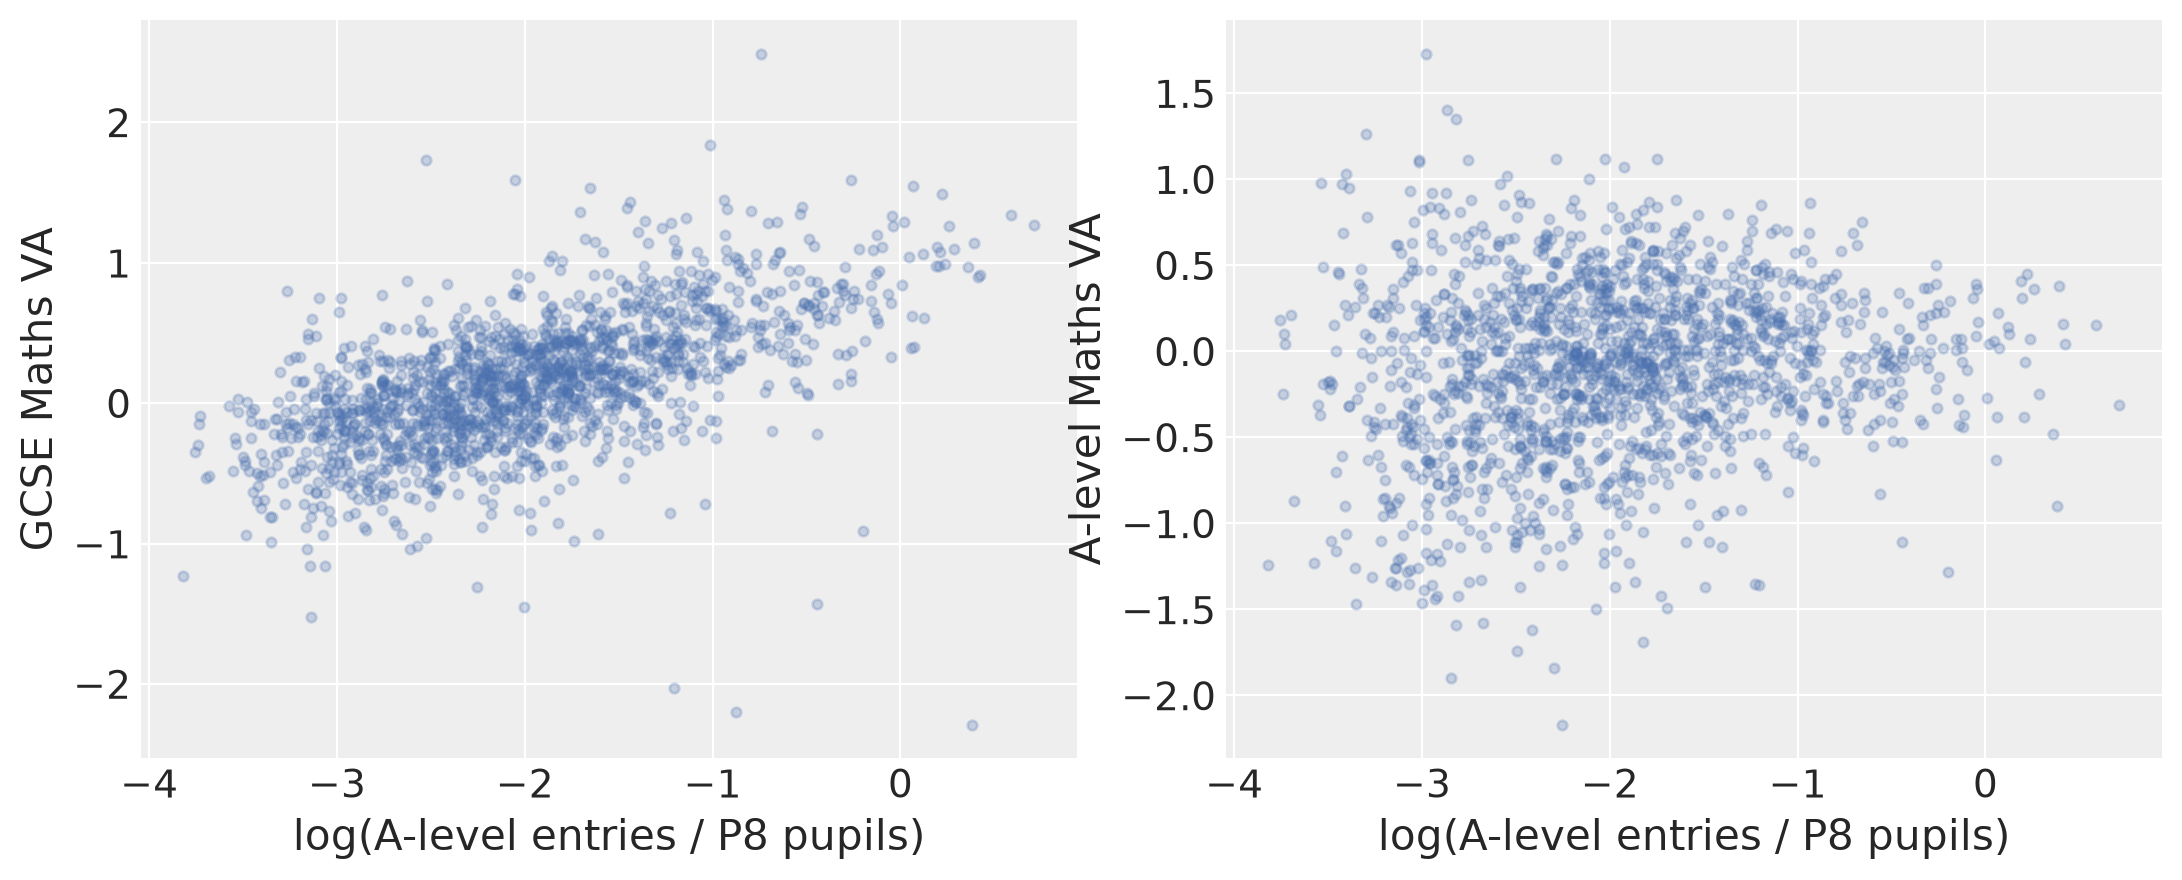

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(df["log_selection_rate"], df["gcse_va"], color="#4C72B0", alpha=0.25, s=12)
axes[0].set_xlabel("log(A-level entries / P8 pupils)")
axes[0].set_ylabel("GCSE Maths VA")
axes[1].scatter(df["log_selection_rate"], df["alevel_va"], color="#4C72B0", alpha=0.25, s=12)
axes[1].set_xlabel("log(A-level entries / P8 pupils)")
axes[1].set_ylabel("A-level Maths VA")
plt.tight_layout()
plt.show()

### Extended model

We extend the structural equation from the first model with a term for the (standardised, log) selection rate, $s_i$:

$$
y_i = \alpha + \beta x_i + \gamma s_i + \epsilon_i, \quad \epsilon_i \sim \text{Normal}(0, \tau_y)
$$

Everything else — the latent true GCSE/A-level VA, the measurement model tying them to the observed scores and their known standard errors — is unchanged. $\gamma$ tells us whether a school's selectivity into A-level Maths predicts its A-level VA *independently* of its GCSE VA; if it does, and it moves `beta` when included, that's a sign the first model's `beta` was partly a selectivity artefact rather than pure carryover.

In [13]:
sel_z = ((df["log_selection_rate"] - df["log_selection_rate"].mean()) / df["log_selection_rate"].std()).to_numpy()

with pm.Model() as eiv_model_selection:
    mu_x = pm.Normal("mu_x", mu=0, sigma=1)
    tau_x = pm.HalfNormal("tau_x", sigma=1)
    x_raw = pm.Normal("x_raw", mu=0, sigma=1, shape=n_schools)
    x_true = pm.Deterministic("x_true", mu_x + tau_x * x_raw)

    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    gamma = pm.Normal("gamma", mu=0, sigma=1)
    tau_y = pm.HalfNormal("tau_y", sigma=1)
    y_raw = pm.Normal("y_raw", mu=0, sigma=1, shape=n_schools)
    y_true = pm.Deterministic(
        "y_true", alpha + beta * x_true + gamma * sel_z + tau_y * y_raw
    )

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=alevel_se, observed=alevel_obs)

with eiv_model_selection:
    idata_selection = pm.sample(
        draws=1000, tune=2000, chains=4, target_accept=0.99,
        random_seed=RANDOM_SEED,
    )
    ppc_selection = pm.sample_posterior_predictive(idata_selection, random_seed=RANDOM_SEED)

idata_selection.update(ppc_selection)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, gamma, tau_y, y_raw]


Output()

Sampling: [alevel_obs, gcse_obs]


Output()

In [14]:
n_divergent = int(idata_selection.sample_stats["diverging"].sum())
print(f"Divergences: {n_divergent}")

az.summary(idata_selection, var_names=["mu_x", "tau_x", "alpha", "beta", "gamma", "tau_y"], round_to=3)

Divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_x,0.140,0.011,0.123,0.157,247.238,357.773,1.010,0.001,0.000
tau_x,0.452,0.008,0.440,0.465,412.073,681.553,1.012,0.000,0.000
alpha,-0.127,0.012,-0.146,-0.108,798.397,1322.293,1.005,0.000,0.000
beta,0.310,0.031,0.261,0.359,522.161,1023.228,1.014,0.001,0.001
gamma,-0.019,0.013,-0.041,0.002,561.034,904.783,1.011,0.001,0.000
tau_y,0.357,0.010,0.340,0.373,1002.970,1460.546,1.001,0.000,0.000


### Did controlling for selection change `beta`?

Compare the posterior of `beta` from the original model against the posterior from this extended one.

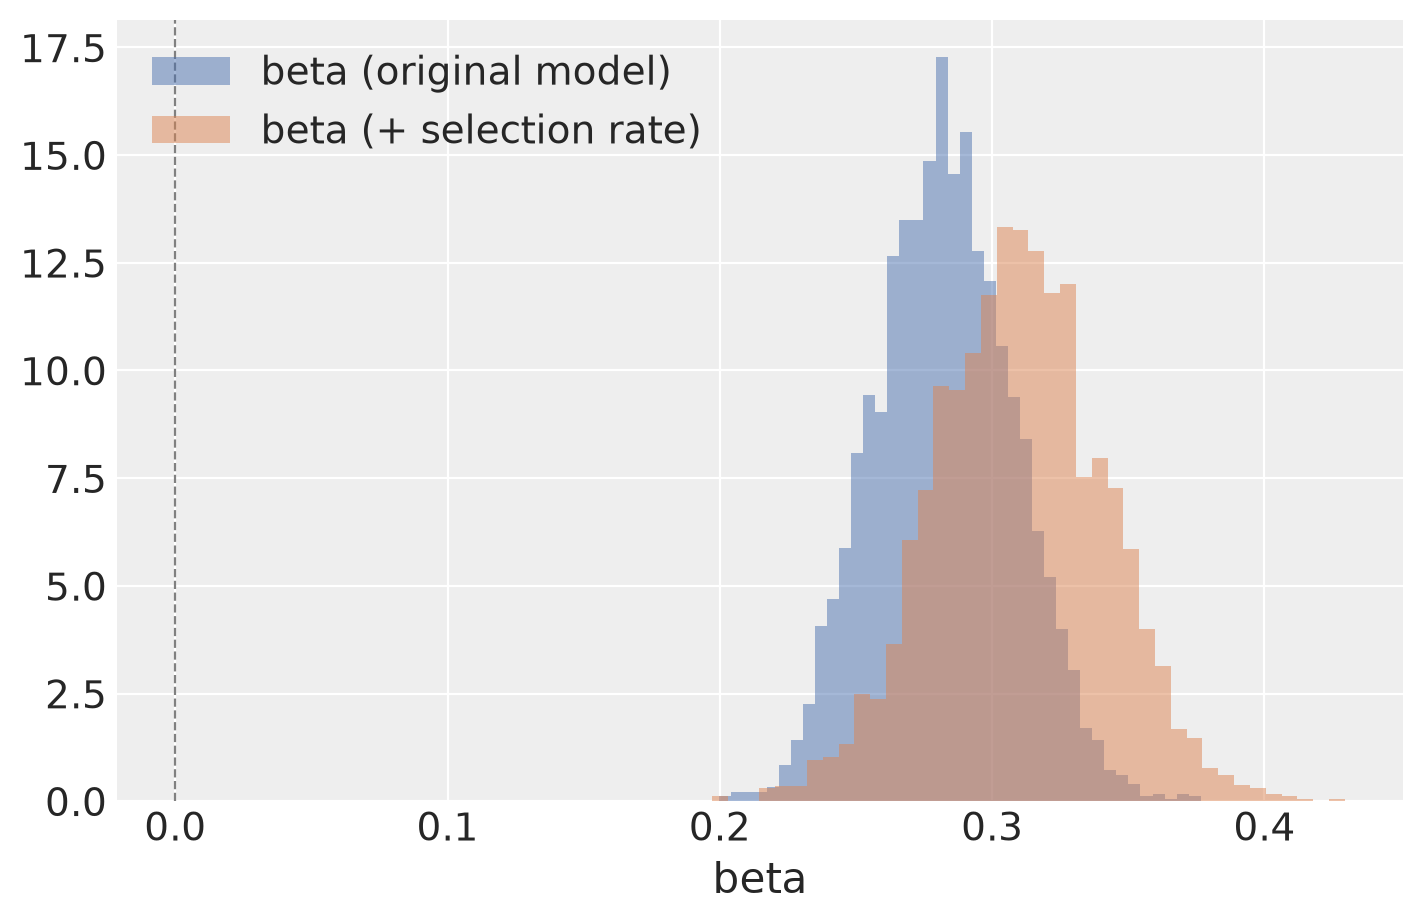

beta, original model:       mean=0.282, sd=0.025
beta, + selection rate:     mean=0.310, sd=0.031
gamma (selection rate effect): mean=-0.019, sd=0.013


In [15]:
beta_original = idata.posterior["beta"].to_numpy().ravel()
beta_selection = idata_selection.posterior["beta"].to_numpy().ravel()
gamma_selection = idata_selection.posterior["gamma"].to_numpy().ravel()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(beta_original, bins=40, density=True, alpha=0.5, color="#4C72B0", label="beta (original model)")
ax.hist(beta_selection, bins=40, density=True, alpha=0.5, color="#DD8452", label="beta (+ selection rate)")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("beta")
ax.legend()
plt.show()

print(f"beta, original model:       mean={beta_original.mean():.3f}, sd={beta_original.std():.3f}")
print(f"beta, + selection rate:     mean={beta_selection.mean():.3f}, sd={beta_selection.std():.3f}")
print(f"gamma (selection rate effect): mean={gamma_selection.mean():.3f}, sd={gamma_selection.std():.3f}")

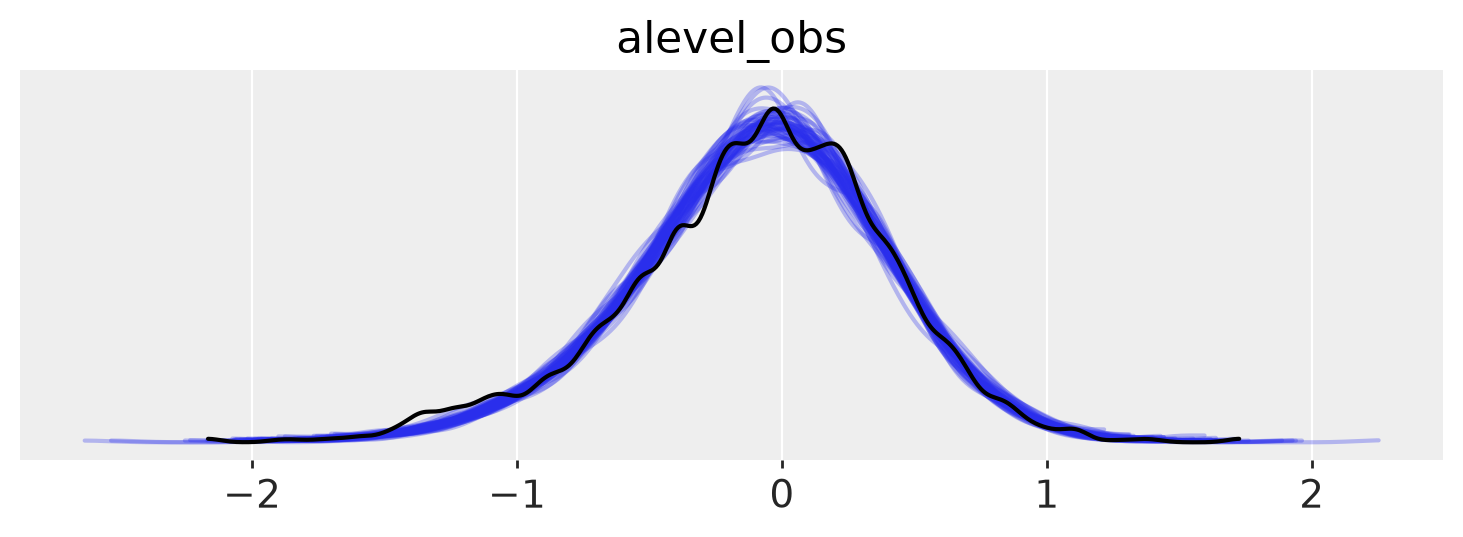

In [16]:
az.plot_ppc_dist(idata_selection, var_names=["alevel_obs"])
plt.show()

## Revised interpretation

If `gamma`'s posterior sits comfortably away from zero and `beta` shrinks once it's included, that's evidence the original model's `beta` was partly picking up a selectivity effect (schools with more/less selective A-level Maths entry systematically differing in A-level VA) rather than pure GCSE-to-A-level carryover. If instead `gamma` is close to zero and `beta` barely moves, that's evidence the original `beta` was already a reasonably clean estimate of carryover — selection into A-level Maths, at least as captured by this entries/cohort-size ratio, isn't doing much independent work once GCSE VA is in the model.

Either way, note the caveat from the EDA above: `A-level Maths entries` can exceed `P8 pupils` (sixth forms recruit externally), so `selection_rate` is a proxy for "size of the A-level Maths cohort relative to the school's GCSE cohort," not a literal within-school continuation rate. A cleaner version of this covariate — e.g. GCSE Maths grade-7-and-above headcount as the denominator, if that becomes available — would let us speak more precisely about within-school selectivity rather than cohort composition.

### Next steps

- Generalise to a **hierarchical multi-subject model**, as originally planned — now with the option of including each subject's own selection-rate covariate where an equivalent entries/cohort measure is available.
- If `gamma` turns out to matter, it's worth also letting `beta` vary with selectivity (an interaction term) rather than assuming carryover is constant regardless of how selective a school's A-level Maths intake is.

## Goodness of fit

So far we've checked that the model *samples* well (no divergences, good $\hat{R}$) and that its posterior predictive distribution roughly overlaps the observed data. Neither tells us how much of the true school-to-school variation in A-level VA is actually explained by GCSE VA. We check three things: whether leave-one-out cross-validation is even usable for this model class, a Bayesian $R^2$ for the structural regression, and calibration of the predictive intervals.

### Why PSIS-LOO doesn't work well here

Our natural instinct would be to rank the two models with PSIS-LOO (`az.loo`/`az.compare`), the standard Bayesian-workflow tool for predictive comparison. But this model has a latent `y_true_i` per school — almost a free parameter per observation, only lightly regularised by `tau_y`. Leaving out school $i$'s `alevel_obs` barely changes the posterior for its own `y_true_i` (it's still pulled there by the structural mean and, for the "no selection" comparison, is otherwise unconstrained), which is exactly the situation where the importance-sampling approximation behind PSIS-LOO breaks down. We check this directly via the Pareto-$k$ diagnostic before trusting any LOO-based comparison.

In [17]:
pm.compute_log_likelihood(idata, var_names=["alevel_obs"], model=eiv_model, progressbar=False)
pm.compute_log_likelihood(idata_selection, var_names=["alevel_obs"], model=eiv_model_selection, progressbar=False)

loo_original = az.loo(idata, var_name="alevel_obs")
print(loo_original)

Computed from 4000 posterior samples and 1622 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -811.58    30.30
p_loo      993.81        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      872   53.8%
   (0.70, 1]   (bad)       671   41.4%
    (1, Inf)   (very bad)   79    4.9%



/opt/conda/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


As expected, a large share of the Pareto-$k$ values are above the 0.7 "bad" threshold and `p_loo` (the estimated effective number of parameters) is close to the number of schools — confirming PSIS-LOO isn't reliable for ranking these two models. We fall back to the two checks below instead.

### Bayesian $R^2$

Following Gelman et al.'s Bayesian $R^2$: for each posterior draw, compute the structural fit $\widehat{y}_i$ (the regression part of the equation for `y_true`) and compare its variance across schools to the residual variance $\tau_y^2$:

$$
R^2 = \frac{\text{Var}_i(\widehat{y}_i)}{\text{Var}_i(\widehat{y}_i) + \tau_y^2}
$$

This gives a full posterior distribution over $R^2$ rather than a single number, and it's defined on the *latent* (true value-added) scale — it asks how much of the school-to-school variation in true A-level VA is explained by true GCSE VA (and selection rate), not how well we predict the noisy observed score.

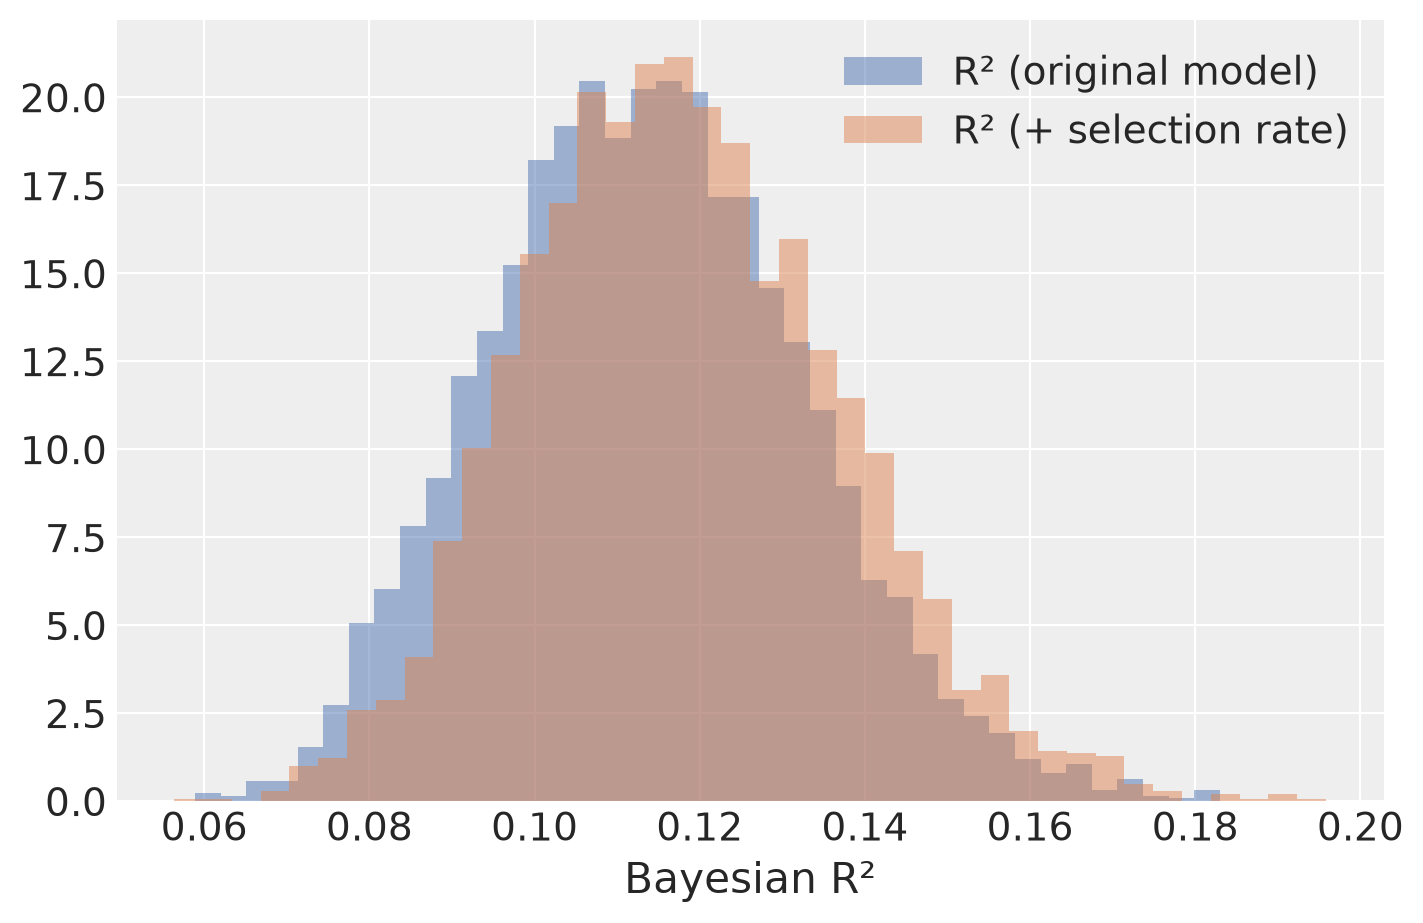

R², original model:   mean=0.114, sd=0.019
R², + selection rate: mean=0.118, sd=0.019


In [18]:
def bayes_r2(idata, has_selection):
    beta_s = idata.posterior["beta"].to_numpy()
    x_true_s = idata.posterior["x_true"].to_numpy()
    tau_y_s = idata.posterior["tau_y"].to_numpy()
    y_hat = beta_s[..., None] * x_true_s
    if has_selection:
        gamma_s = idata.posterior["gamma"].to_numpy()
        y_hat = y_hat + gamma_s[..., None] * sel_z
    var_fit = y_hat.var(axis=-1)
    return (var_fit / (var_fit + tau_y_s**2)).ravel()

r2_original = bayes_r2(idata, has_selection=False)
r2_selection = bayes_r2(idata_selection, has_selection=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(r2_original, bins=40, density=True, alpha=0.5, color="#4C72B0", label="R² (original model)")
ax.hist(r2_selection, bins=40, density=True, alpha=0.5, color="#DD8452", label="R² (+ selection rate)")
ax.set_xlabel("Bayesian R²")
ax.legend()
plt.show()

print(f"R², original model:   mean={r2_original.mean():.3f}, sd={r2_original.std():.3f}")
print(f"R², + selection rate: mean={r2_selection.mean():.3f}, sd={r2_selection.std():.3f}")

### Predictive calibration

A well-calibrated model's $p\%$ posterior predictive interval should contain the observed value about $p\%$ of the time. We check this at a few interval widths for `alevel_obs`.

In [19]:
def coverage_table(idata, observed, var_name, levels=(0.5, 0.8, 0.94)):
    pred = idata.posterior_predictive[var_name].to_numpy()
    pred = pred.reshape(-1, pred.shape[-1])
    rows = []
    for level in levels:
        lo_q, hi_q = 50 * (1 - level), 50 * (1 + level)
        lo = np.percentile(pred, lo_q, axis=0)
        hi = np.percentile(pred, hi_q, axis=0)
        empirical = np.mean((observed >= lo) & (observed <= hi))
        rows.append({"nominal": level, "empirical": empirical})
    return pd.DataFrame(rows)

print("Original model:")
print(coverage_table(idata, alevel_obs, "alevel_obs"))
print("\n+ Selection rate model:")
print(coverage_table(idata_selection, alevel_obs, "alevel_obs"))

Original model:


   nominal  empirical
0     0.50   0.837855
1     0.80   0.976572
2     0.94   0.998150

+ Selection rate model:


   nominal  empirical
0     0.50   0.836621
1     0.80   0.977189
2     0.94   0.998767


### Summary

- **Sampling** is healthy (0 divergences, $\hat{R} \le 1.02$) — the model fits *computationally* without issue.
- **PSIS-LOO is not usable** for comparing these two models: 41% of Pareto-$k$ values are "bad" and 5% "very bad" ($p_{loo} \approx 994$, close to the number of schools), because of the per-school latent structure.
- **Bayesian $R^2 \approx 0.11$–0.12**: true GCSE Maths VA (and selection rate) explains only around a tenth of the school-to-school variance in true A-level Maths VA. The relationship we found earlier (`beta` clearly positive, away from zero) is real, but it is a modest predictor, not a strong one — most of the variation in a school's A-level Maths value-added is *not* explained by its GCSE Maths value-added.
- **Calibration is over-conservative, not just "slightly"**: the nominal 50% interval actually covers ~84% of observations, 80% covers ~98%, and 94% covers ~99.8%. The model isn't overconfident, but it's also not sharp — its predictive intervals for an individual school's A-level VA are wider than they need to be. That's worth investigating (e.g. whether the published confidence intervals we derived `sigma` from are themselves conservative, or whether `tau_y` is absorbing structure it shouldn't) rather than taken as a clean pass.

## Validating the published confidence-interval formula

DfE derives each school's confidence interval as $\pm 1.96 \times \sigma_{national} / \sqrt{n}$, where $\sigma_{national}$ is a fixed national pupil-level standard deviation for that measure and $n$ is the size of the cohort the score is based on. Since we now have cohort sizes (`A-level Maths entries`, and `P8 pupils` as a proxy for the GCSE Maths cohort, since Maths is compulsory), we can check this directly: $se_i \times \sqrt{n_i}$ should come out to the same constant, $\sigma_{national}$, for every school.

In [20]:
implied_sd_alevel = df["alevel_se"] * np.sqrt(df["alevel_entries"])
implied_sd_gcse = df["gcse_se"] * np.sqrt(df["p8_pupils"])

print("Implied national SD, A-level Maths:")
print(implied_sd_alevel.describe())
print("\nImplied national SD, GCSE Maths (P8MEAMAT):")
print(implied_sd_gcse.describe())

Implied national SD, A-level Maths:
count    1622.000000
mean        1.228256
std         0.006354
min         1.195229
25%         1.224490
50%         1.227476
75%         1.232143
max         1.253899
dtype: float64

Implied national SD, GCSE Maths (P8MEAMAT):
count    1622.000000
mean        1.486696
std         0.014995
min         1.444229
25%         1.476527
50%         1.487245
75%         1.496403
max         1.525715
dtype: float64


This comes out essentially constant across all 1,622 schools — SD of the implied national SD is under 2% of its mean in both cases (the tiny remaining spread is just rounding noise from the published bounds being rounded to 2 decimal places). That confirms the formula, and confirms our `se = (upper - lower) / (2 * 1.96)` derivation was recovering exactly the right quantity: **≈1.23** national SD per pupil for A-level Maths, **≈1.49** for GCSE Maths (`P8MEAMAT`).

This matters for how we should think about `alevel_se`/`gcse_se` in the model: they represent pure *sampling* noise from averaging over a finite number of pupils at a fixed national per-pupil dispersion — not anything related to teaching quality or genuine school-level variation. That's exactly the role we gave them in the errors-in-variables model, as opposed to `tau_x`/`tau_y`, which represent genuine between-school variation in the *true* value-added. The two are conceptually distinct and the data confirms `se_i` is doing what we assumed.

## Digging into `tau_y`: is the calibration check even fair?

The overall calibration check earlier pooled all 1,622 schools together, but they range from 6 to 280 A-level Maths entries — a huge range in how informative each school's own observation is. We stratify the same check by cohort size to see whether the "over-conservative" verdict holds everywhere, or is being driven by one part of the range.

In [21]:
pred = idata.posterior_predictive["alevel_obs"].to_numpy().reshape(-1, n_schools)
pred_mean = pred.mean(axis=0)
pred_sd = pred.std(axis=0)

df["std_resid"] = (alevel_obs - pred_mean) / pred_sd
df["abs_std_resid"] = df["std_resid"].abs()

lo50 = np.percentile(pred, 25, axis=0)
hi50 = np.percentile(pred, 75, axis=0)
df["covered_50"] = (alevel_obs >= lo50) & (alevel_obs <= hi50)

entry_quartile = pd.qcut(df["alevel_entries"], 4)
stratified = df.groupby(entry_quartile, observed=True).agg(
    mean_abs_std_resid=("abs_std_resid", "mean"),
    coverage_50=("covered_50", "mean"),
    n_schools=("URN", "count"),
)
stratified

,mean_abs_std_resid,coverage_50,n_schools
alevel_entries,,,
"(5.999, 14.0]",0.573065,0.648961,433
"(14.0, 24.0]",0.419285,0.805627,391
"(24.0, 45.0]",0.316565,0.917500,400
"(45.0, 280.0]",0.179017,0.994975,398


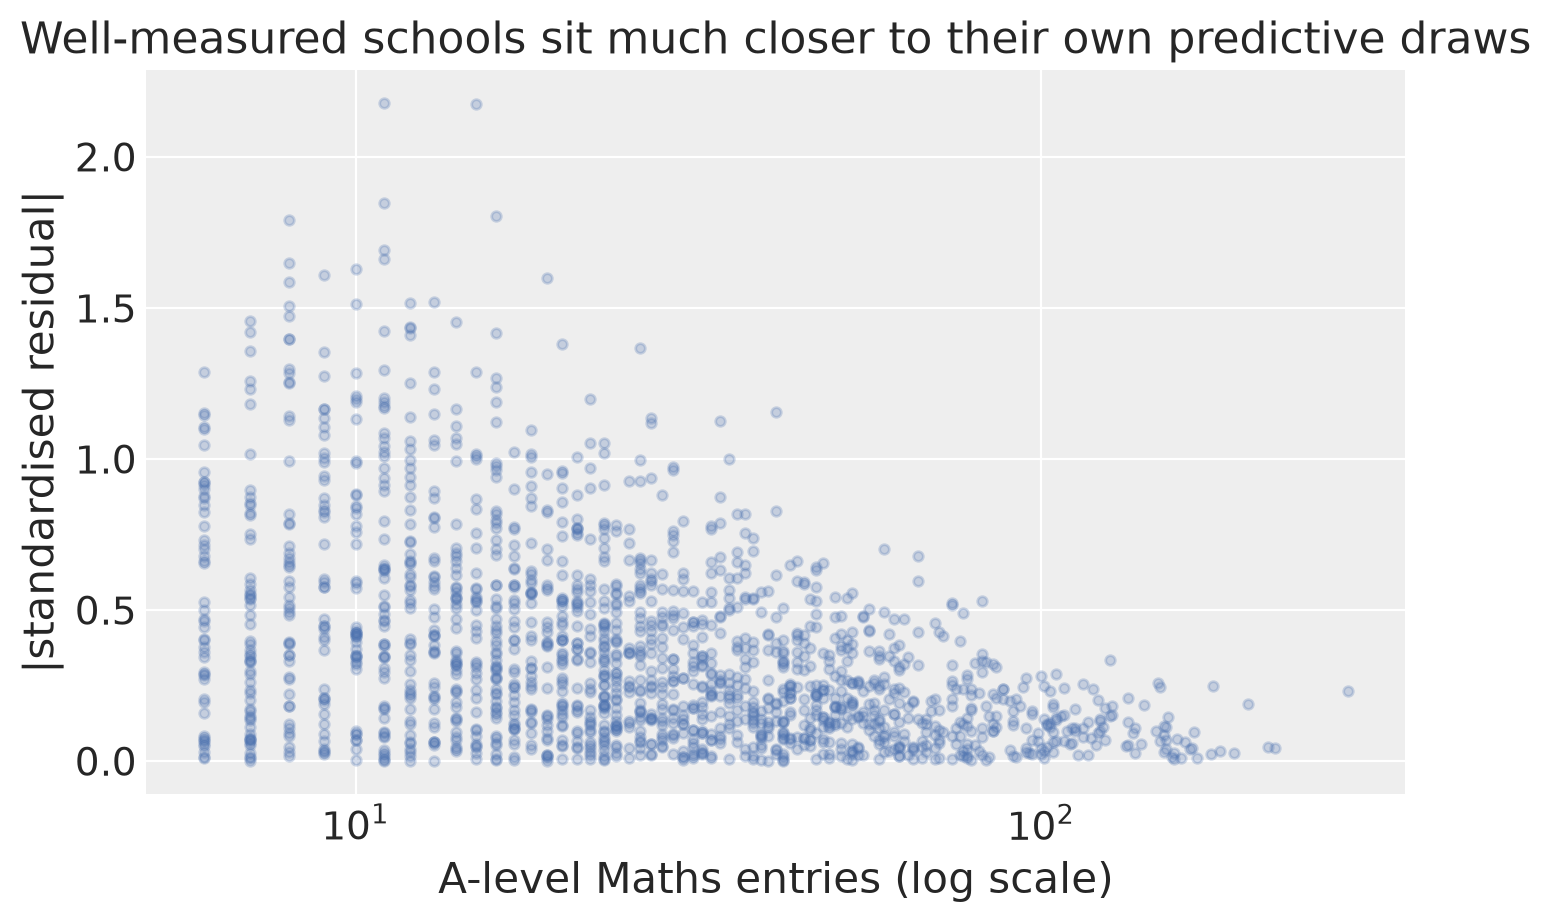

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["alevel_entries"], df["abs_std_resid"], color="#4C72B0", alpha=0.25, s=12)
ax.set_xscale("log")
ax.set_xlabel("A-level Maths entries (log scale)")
ax.set_ylabel("|standardised residual|")
ax.set_title("Well-measured schools sit much closer to their own predictive draws")
plt.show()

### Why this happens — and what it means for `tau_y`

Coverage climbs steeply with cohort size: the smallest-entries quartile sits closest to the nominal 50% rate, while the largest-entries quartile covers almost every point. That gradient has a specific cause, and it's the same one that broke PSIS-LOO earlier.

For a well-measured school, `alevel_se` is tiny relative to `tau_y` (e.g. `se ≈ 0.07` for a 280-entry school vs. `tau_y ≈ 0.36`). The likelihood then dominates the structural prior for that school's `y_true_i`, so its posterior collapses to sit almost exactly on top of its own observed `alevel_va`. When we then draw posterior-predictive replicates, they're generated from a `y_true_i` that's essentially a copy of the original data point — so of course the replicate lands close to the observation. That's not a genuine test of the model; it's largely circular for exactly the schools where `alevel_se` is smallest. It's the identical mechanism that made per-school Pareto-$k$ values blow up in the PSIS-LOO check: a latent parameter that's almost fully determined by its own single data point.

For a small-cohort school, `alevel_se` and `tau_y` are comparable in size, so there's genuine partial pooling — `y_true_i` is a real blend of the school's own noisy observation and the population regression line, and the posterior-predictive check is a fairer (if still not fully honest, in-sample) test. That's why the smallest-entries quartile's coverage is much closer to nominal.

The upshot: **the earlier "over-conservative calibration" conclusion needs qualifying, not `tau_y` itself.** `tau_y`'s value (≈0.36) is mainly informed by the well-measured schools — precisely because their `y_true_i` is pinned close to the data, comparing that to the regression line is a legitimate (not circular) way to *estimate* `tau_y`. It's only the *predictive check*, which reuses that same pinned-down `y_true_i` to generate new replicate data and compares it back to the same observation, that's compromised for those schools. So there isn't strong evidence here that `tau_y` is mis-specified or too wide — the real, defensible finding is still the $R^2 \approx 0.11$: most of the genuine variation `tau_y` represents just isn't explained by GCSE VA. A trustworthy calibration check would need actual held-out data (a different exam year) or refitting the model leaving each school out in turn — both real options, but out of scope here given the cost of refitting a NUTS model per school.

### Residual vs. GCSE value-added

One more standard check: plot the standardised residual against the predictor itself. If the linear structural relationship (`y_true = alpha + beta * x_true`) is adequate, there should be no remaining trend — the residuals should scatter evenly around zero across the whole range of GCSE VA. A visible slope or curve would mean `beta` (a single linear slope) is missing some real nonlinearity in how GCSE VA relates to A-level VA.

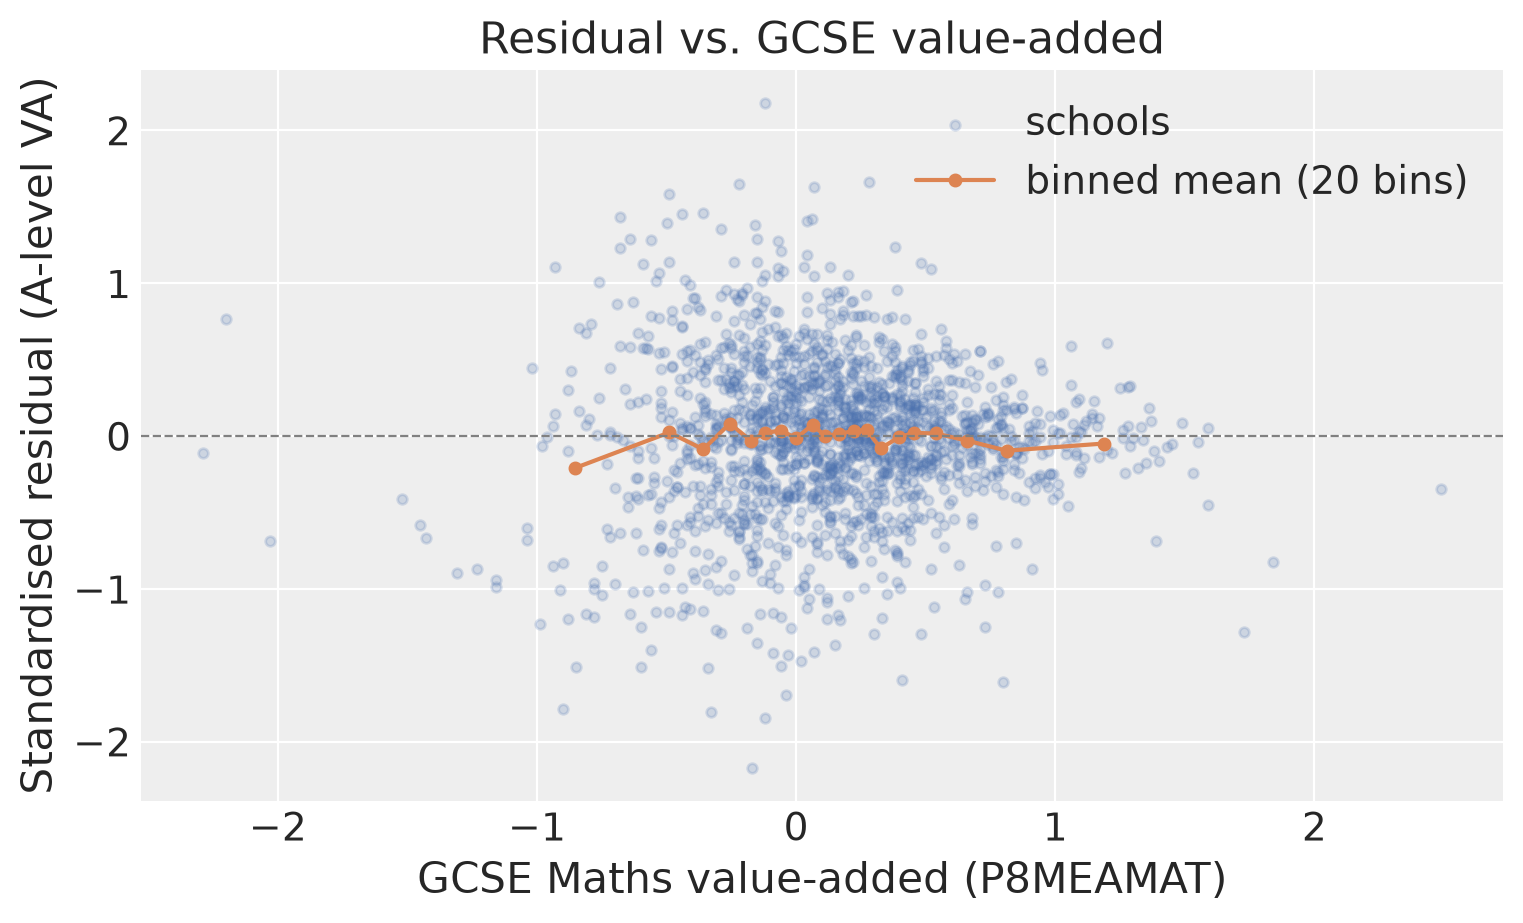

In [23]:
gcse_bins = pd.qcut(df["gcse_va"], 20)
binned = df.groupby(gcse_bins, observed=True).agg(
    gcse_va=("gcse_va", "mean"), std_resid=("std_resid", "mean")
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(df["gcse_va"], df["std_resid"], color="#4C72B0", alpha=0.2, s=12, label="schools")
ax.plot(binned["gcse_va"], binned["std_resid"], color="#DD8452", marker="o", markersize=4, linewidth=1.5, label="binned mean (20 bins)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("GCSE Maths value-added (P8MEAMAT)")
ax.set_ylabel("Standardised residual (A-level VA)")
ax.set_title("Residual vs. GCSE value-added")
ax.legend()
plt.show()

The binned mean sits close to zero across essentially the whole range of GCSE VA, with no visible slope or curve — a small dip at the low and high ends is just the thinner tails (fewer schools there) making the bin averages noisier, not a real trend. That's a clean result: a single linear `beta` looks like an adequate description of how GCSE VA relates to A-level VA — there's no sign we're missing a nonlinearity (e.g. diminishing returns for already-high-VA schools). The spread of the point cloud itself doesn't visibly narrow or widen across the x-axis either, so the earlier residual-magnitude gradient we found is specifically a cohort-size effect, not something driven by the level of GCSE VA.